In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/my_project_ml_fresh/data/credit.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

In [ ]:
numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "YearsExperience"
]

display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,43.584600,14.919094,18.0,31.00,43.0,56.00,69.0
Income,4804.0,49738.123022,15101.361851,-3731.0,39608.50,49488.0,59917.00,99146.0
LoanAmount,5000.0,19870.768600,8046.542413,-10059.0,14455.25,19842.5,25326.75,48353.0
CreditScore,4806.0,575.494590,160.550839,300.0,433.00,579.0,712.00,849.0
YearsExperience,5000.0,19.599000,11.516837,0.0,10.00,20.0,29.00,39.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features and target
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

# Identify columns
numeric_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "YearsExperience"
]

categorical_features = [
    "Gender",
    "Education",
    "City",
    "EmploymentType"
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

Training samples: 4000
Testing samples: 1000

Training target distribution:
LoanApproved
0    3079
1     921
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Baseline model
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
baseline_model.fit(X_train, y_train)

# Predictions
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

# Metrics
print("Baseline Model Performance")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Model Performance
Accuracy : 0.885
Precision: 0.7778
Recall   : 0.7
F1 Score : 0.7368
ROC-AUC  : 0.9113

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       770
           1       0.78      0.70      0.74       230

    accuracy                           0.89      1000
   macro avg       0.85      0.82      0.83      1000
weighted avg       0.88      0.89      0.88      1000



In [ ]:
# Class-balanced Logistic Regression

balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
balanced_model.fit(X_train, y_train)

# Predictions
y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

# Metrics
print("Class-Balanced Logistic Regression")
print("=" * 45)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_balanced), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_balanced), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_balanced), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_balanced), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_balanced), 4
))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

Class-Balanced Logistic Regression
Accuracy : 0.846
Precision: 0.6131
Recall   : 0.8957
F1 Score : 0.7279
ROC-AUC  : 0.911

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       770
           1       0.61      0.90      0.73       230

    accuracy                           0.85      1000
   macro avg       0.79      0.86      0.81      1000
weighted avg       0.88      0.85      0.85      1000



In [ ]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative class:", negative)
print("Positive class:", positive)
print("Scale Pos Weight:", round(scale_pos_weight, 3))

# XGBoost model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\nXGBoost Performance")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_xgb), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_xgb), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_xgb), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_xgb), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_xgb), 4
))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

Negative class: 3079
Positive class: 921
Scale Pos Weight: 3.343

XGBoost Performance
Accuracy : 0.962
Precision: 0.9444
Recall   : 0.887
F1 Score : 0.9148
ROC-AUC  : 0.9287

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       770
           1       0.94      0.89      0.91       230

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



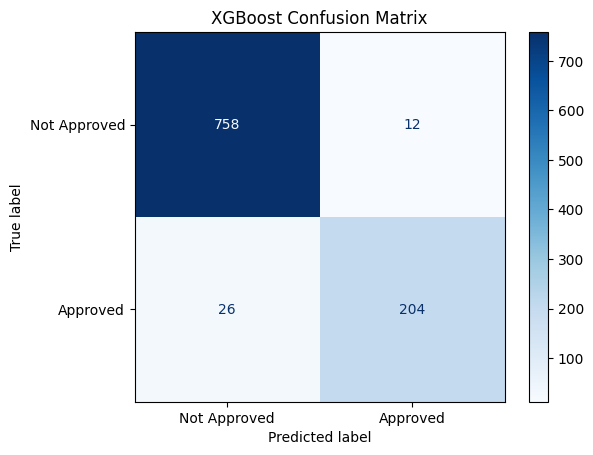

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["Not Approved", "Approved"],
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
# Get feature names after preprocessing
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Get XGBoost feature importance
importances = xgb_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
17,cat__EmploymentType_Unemployed,0.370615
3,num__CreditScore,0.153175
16,cat__EmploymentType_Self-Employed,0.093623
1,num__Income,0.078053
15,cat__EmploymentType_Salaried,0.052694
2,num__LoanAmount,0.022359
13,cat__City_New York,0.022160
10,cat__Education_PhD,0.021979
0,num__Age,0.021523
6,cat__Gender_Male,0.021511


<Figure size 800x600 with 0 Axes>

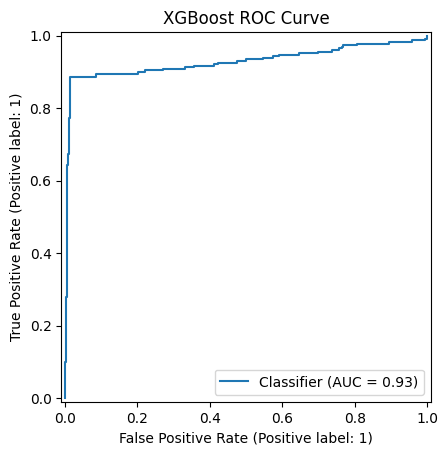

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost ROC Curve")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "XGBoost"
    ],
    "Precision": [
        0.7778,
        0.6131,
        0.9444
    ],
    "Recall": [
        0.7000,
        0.8957,
        0.8870
    ],
    "F1 Score": [
        0.7368,
        0.7279,
        0.9148
    ],
    "ROC-AUC": [
        0.9113,
        0.9110,
        0.9287
    ]
})

display(comparison)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7778,0.7000,0.7368,0.9113
1,Balanced Logistic Regression,0.6131,0.8957,0.7279,0.9110
2,XGBoost,0.9444,0.8870,0.9148,0.9287


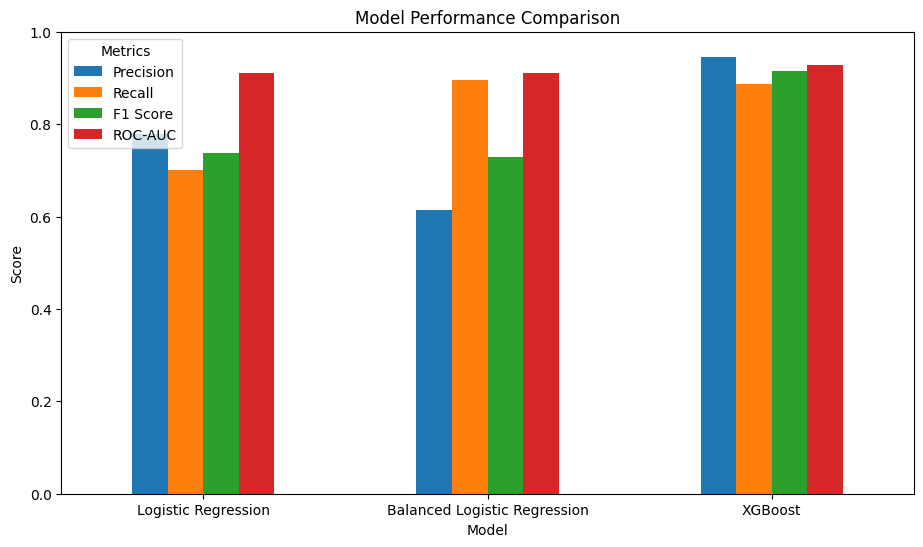

In [ ]:
metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

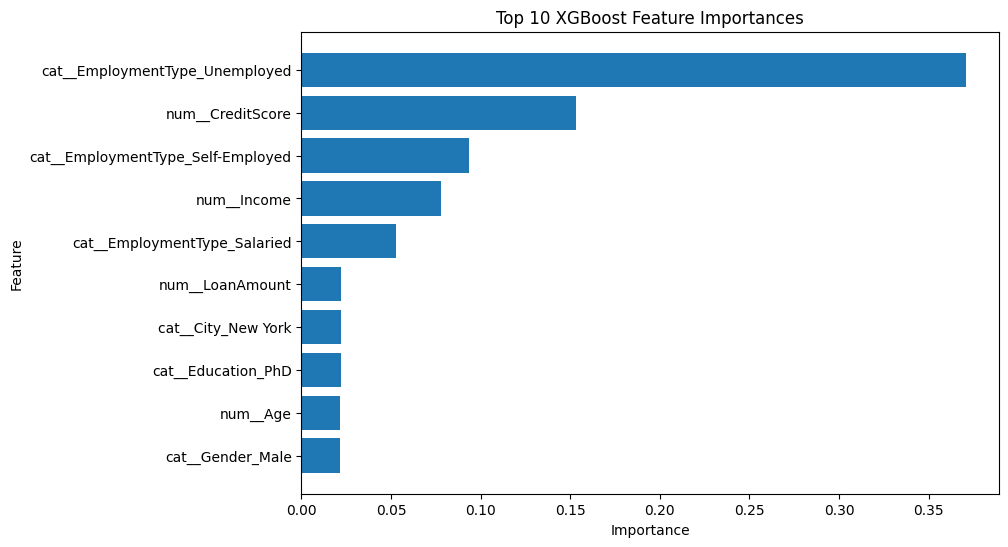

In [ ]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
